# Practice-2: granular column collapse

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import sys
sys.path.append('../')
import utils
import visualizer
import drucker_prager

## Problem

This example considers a granular column collapse problem. The column is represented with material points and then subjected to a collapse due to gravity. The particles are modeled using the Drucker-Prager plasticity model.

![practice-2](https://raw.githubusercontent.com/yjchoi1/learn-mpm-2d/main/book/figs/granular_column_collapse.png)

## Material properties

In [2]:
# Material properties
E = 100000
nu = 0.3
rho = 3600
mu = 0.385
phi = 30
c = 1
K0 = 0.5

## Analysis setting

In [3]:
# Analysis setting
dtime = 0.0001
time = 1
t = 0
interval = 200
g = 4.8

## Mesh generation

In [4]:
# length of domain
l = 1

# number of elements for each dim
n_ele_x = 20
n_ele_y = 20

# cell size
delta_x = l / n_ele_x
delta_y = l / n_ele_y

# number of grid nodes
n_node_x = n_ele_x + 1
n_node_y = n_ele_y + 1
n_nodes = n_node_x * n_node_y

# Generate mesh nodes
x_coords = np.linspace(0, l, n_node_x)
y_coords = np.linspace(0, l, n_node_y)
X, Y = np.meshgrid(x_coords, y_coords)
nodes = np.vstack([X.flatten(), Y.flatten()]).T

# Generate elements (connectivity)
elements = []
for j in range(n_node_y - 1):
    for i in range(n_node_x - 1):
        n1 = j * n_node_x + i
        n2 = n1 + 1
        n3 = n2 + n_node_x
        n4 = n1 + n_node_x
        elements.append([n1, n2, n3, n4])
elements = np.array(elements)
elements_coordinate_map = nodes[elements]
n_elements = elements.shape[0]

# Boundary nodes
bottomNodes = np.where(nodes[:, 1] < 1e-8)[0]
upperNodes = np.where(nodes[:, 1] > l - 1e-8)[0]
leftNodes = np.where(nodes[:, 0] < 1e-8)[0]
rightNodes = np.where(nodes[:, 0] > l - 1e-8)[0]

# Initialize node quantities
n_masses = np.zeros(n_nodes)  # nodal masses
n_momentums = np.zeros((n_nodes, 2))  # nodal momentums
n_iforces = np.zeros((n_nodes, 2))  # Internal forces
n_eforces = np.zeros((n_nodes, 2))  # External forces. Not used in this practice
# Initialize grid state variables
gStress = np.zeros((3, n_nodes))  # [sig_xx, sig_yy, sig_xy]
gDisp = np.zeros((2, n_nodes))  # [disp_x, disp_y]


## Generate particles

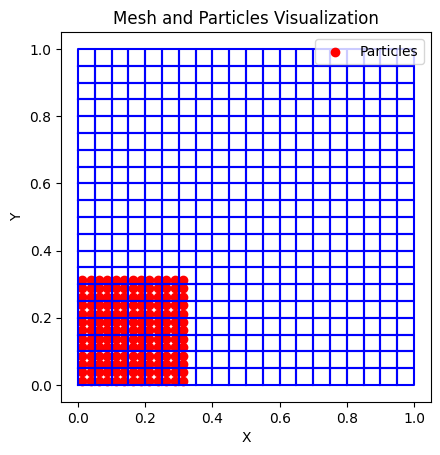

In [15]:
# Inputs for particles representing granular column
origin = [0.0125, 0.0125]
lengths = [0.300, 0.300]
n_particle_per_cell_per_dim = 2

# Generate particles for granular column body
spacing = delta_x / n_particle_per_cell_per_dim
xp = utils.generate_rectangular_particles(
    origin=origin, length=lengths[0], height=lengths[1], spacing=spacing)

# particle states
vp = np.zeros(xp.shape)
s = np.zeros((len(xp), 3))  # [sigma_xx, sigma_yy, sigma_xy]
eps = np.zeros((len(xp), 3))  # [epsilon_xx, epsilon_yy, gamma_xy]
Fp = np.tile([1.0, 0.0, 0.0, 1.0], (len(xp), 1))

# Find elements to which particles belong
ele_ids_of_particles, p_ids_in_eles = utils.particle_element_mapping(
    xp, delta_x, delta_y, n_ele_x, n_elements)
active_elements = np.unique(ele_ids_of_particles)
active_nodes = np.unique(elements[active_elements, :])

# Compute initial particle volume
Vp = np.zeros(len(xp))
# Volume (area) of each background cell
for p_ids_in_ele in p_ids_in_eles:
    n_mp_in_element = len(p_ids_in_ele)
    if n_mp_in_element > 0:
        volume_per_mp = (delta_x * delta_y) / n_mp_in_element
        Vp[p_ids_in_ele] = volume_per_mp
Vp0 = Vp.copy()  # save initial volume
Mp = Vp * rho  # mass of particles

# Initialize stress
height = lengths[1] + spacing / 2
s[:, 1] = - g * rho * (height - xp[:, 1])
s[:, 0] = K0 * s[:, 1]

# Plot mesh, particles
meshes = [(nodes, elements)]
visualizer.plot_mesh_and_particles(nodes, elements, xp)

## Run analysis

Simulating: 100%|██████████| 10000/10000 [06:23<00:00, 26.06it/s]


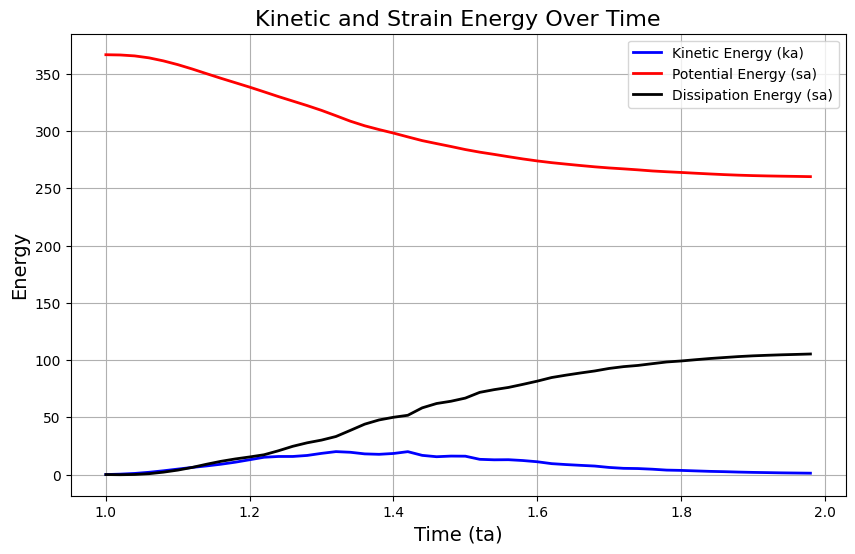

In [16]:
# Results to save
ta = []  # time
ka = []  # kinetic energy
pa = []  # potential energy
da = []  # dissipation energy
# sa = []  # strain energy
pos = []  # positions
vel = []  # velocities

nsteps = int(time / dtime)

istep = 0
potential_e_t0 = np.sum(Mp * g *  xp[:, 1])


for istep in tqdm(range(nsteps), desc="Simulating"):
    # print(f"Time: {t:.5f}/{time}")
    
    # Compute potential energy
    potential_e = np.sum(Mp * g *  xp[:, 1])
    kinetic_e = np.sum(0.5 * Mp * np.linalg.norm(vp, axis=1)**2)
    dissipation_e = potential_e_t0 - kinetic_e - potential_e

    # Refresh the nodal values
    n_masses.fill(0)
    n_momentums.fill(0)
    n_iforces.fill(0)
    n_eforces.fill(0)
    gStress.fill(0)
    
    # Iterate over the computational cells (i.e., elements)
    for ele_id in active_elements:
        # node ids of the current element
        node_ids = elements[ele_id]
        # coords of the current element
        node_coords = nodes[node_ids, :]  
        # particle ids inside the current element
        material_points = p_ids_in_eles[ele_id]

        # Iterate over the material points in the current cell
        for p in material_points:
            
            # Convert global coordinate "p=(x, y)" to local coordiate "pt=(xi, eta)".
            pt = np.array(
                [(2 * xp[p, 0] - (node_coords[0, 0] + node_coords[1, 0])) / delta_x,
                 (2 * xp[p, 1] - (node_coords[1, 1] + node_coords[2, 1])) / delta_y])

            # Evaluate shape function and its derivatives with respect to local coords (xi, eta) at (x, y).
            N, dNdxi = utils.lagrange_basis("Q4", pt)
            # Evaluate the Jacobian at current the current local coords (xi, eta).
            J0 = node_coords.T @ dNdxi
            # Get the inverse of Jacobian
            invJ0 = np.linalg.inv(J0)
            # Get the derivative of shape function with respect to global coords, i.e., (x, y)
            dNdx = dNdxi @ invJ0

            # Current stress of material points
            stress = s[p, :]
            
            # Iterate over the nodes of the current element & update nodal values by interpolating material point values
            for i, node_id in enumerate(node_ids):
                dNIdx = dNdx[i, 0]
                dNIdy = dNdx[i, 1]
                n_masses[node_id] += N[i] * Mp[p]
                n_momentums[node_id, :] += N[i] * Mp[p] * vp[p, :]
                n_iforces[node_id, 0] -= Vp[p] * (stress[0] * dNIdx + stress[2] * dNIdy)
                n_iforces[node_id, 1] -= Vp[p] * (stress[2] * dNIdx + stress[1] * dNIdy)
                n_eforces[node_id, 1] -= N[i] * Mp[p] * g

    # Total nodal force
    nforce = n_iforces + n_eforces
    
    # Compute nodal accelerations
    n_accelerations = np.zeros((n_nodes, 2))
    # valid_mass = n_masses > 1e-12
    # n_accelerations[valid_mass, :] = nforce[valid_mass, :] / n_masses[valid_mass, None]
    n_accelerations[active_nodes, :] = nforce[active_nodes, :] / n_masses[active_nodes, None]
    
    
    # Boundary conditions
    # 0. Update nodal kinematics (nodal mass, momentum -> particles)
    # 1. Velocity & acceleration to 0
    # 2. Compute nodal force.
    #   * First, map particle body force to nodal body force
    #   * Next, map particle internal force to nodel internal force
    # 3. compute_particle_kinematics.
    #   * compute_acceleration_velocity
    #       * accel = (f_e + f_i) / mass
    #       * apply_friction_constraints
    #       * vel += accel * dt
    #       * apply_velocity_constraints
    #   * compute_updated_position
    
    
    # Function to apply frictional boundary condition on given nodes
    def apply_frictional_boundary_condition(node_ids, dir_n, sign_dir_n):
        dir_t = 1 - dir_n  # Tangential direction

        # Normal and tangential accelerations
        acc_n = n_accelerations[node_ids, dir_n]
        acc_t = n_accelerations[node_ids, dir_t]

        # Tangential velocities
        vel_t = n_momentums[node_ids, dir_t] / n_masses[node_ids]

        # Determine nodes where particles are acting towards the boundary
        positive_movement_towards_boundary = (acc_n * sign_dir_n) > 0.0

        # Apply frictional boundary condition
        for idx in np.where(positive_movement_towards_boundary)[0]:
            node_id = node_ids[idx]
            acc_n_i = acc_n[idx]
            acc_t_i = acc_t[idx]
            vel_t_i = vel_t[idx]
            # print(vel_t_i)
            
            # Determine static or kinetic friction
            if vel_t_i != 0.0:  # Kinetic friction
                # compute tangential velocity at next timestep
                vel_net = dtime * acc_t_i + vel_t_i
                vel_frictional = dtime * mu * abs(acc_n_i)
                if abs(vel_net) <= vel_frictional:
                    # friction stops the particle
                    acc_t_i = -vel_t_i / dtime
                else:
                    # friction reduces the tangential acceleration
                    acc_t_i -= np.sign(vel_net) * mu * abs(acc_n_i)
                # acc_t_i -= np.sign(vel_net) * mu * abs(acc_n_i)
            else:  # Static friction
                if abs(acc_t_i) <= mu * abs(acc_n_i):
                    acc_t_i = 0.0
                else:
                    acc_t_i -= np.sign(acc_t_i) * mu * abs(acc_n_i)

            # Update tangential acceleration
            n_accelerations[node_id, dir_t] = acc_t_i

            # Update nodal force at this node
            nforce[node_id, :] = n_accelerations[node_id, :] * n_masses[node_id]
    
    apply_frictional_boundary_condition(
        np.intersect1d(leftNodes, active_nodes), dir_n=0, sign_dir_n=-1.0)
    apply_frictional_boundary_condition(
        np.intersect1d(rightNodes, active_nodes), dir_n=0, sign_dir_n=1.0)
    apply_frictional_boundary_condition(
        np.intersect1d(bottomNodes, active_nodes), dir_n=1, sign_dir_n=-1.0)
    apply_frictional_boundary_condition(
        np.intersect1d(upperNodes, active_nodes), dir_n=1, sign_dir_n=1.0)
    
    # Impose boundary condition
    n_momentums[leftNodes, 0] = 0
    n_momentums[rightNodes, 0] = 0
    n_momentums[bottomNodes, 1] = 0
    n_momentums[upperNodes, 1] = 0
    nforce[leftNodes, 0] = 0
    nforce[rightNodes, 0] = 0
    nforce[bottomNodes, 1] = 0
    nforce[upperNodes, 1] = 0
    
    # Update nomal momentum
    n_momentums += nforce * dtime    
    
    k = 0
    u = 0
    
    # Iterate over the computational cells (i.e., elements)
    for ele_id in active_elements:
        # node ids of the current element
        node_ids = elements[ele_id]
        # coords of the current element
        node_coords = nodes[node_ids, :]  
        # particle ids inside the current element
        material_points = p_ids_in_eles[ele_id]

        # Iterate over the material points in the current cell
        for p in material_points:
            # Convert global coordinate "p=(x, y)" to local coordiate "pt=(xi, eta)".
            pt = np.array(
                [(2 * xp[p, 0] - (node_coords[0, 0] + node_coords[1, 0])) / delta_x,
                 (2 * xp[p, 1] - (node_coords[1, 1] + node_coords[2, 1])) / delta_y])

            N, dNdxi = utils.lagrange_basis("Q4", pt)
            J0 = node_coords.T @ dNdxi
            invJ0 = np.linalg.inv(J0)
            dNdx = dNdxi @ invJ0
            Lp = np.zeros((2, 2))
            
            for i, node_id in enumerate(node_ids):  
                vI = np.zeros(2)
                vp[p, :] += dtime * N[i] * nforce[node_id, :] / n_masses[node_id]
                xp[p, :] += dtime * N[i] * n_momentums[node_id, :] / n_masses[node_id]
                vI = n_momentums[node_id, :] / n_masses[node_id]  # nodal velocity
                Lp += vI.reshape(2, 1) @ dNdx[i, :].reshape(1, 2)  # particle velocity gradient

            F = Fp[p, :].reshape(2, 2) @ (np.eye(2) + Lp * dtime)
            Fp[p, :] = F.flatten()
            Vp[p] = np.linalg.det(F) * Vp0[p]
            dEps = dtime * 0.5 * (Lp + Lp.T)
            
            D = drucker_prager.elasticity_matrix(E, nu)
            alpha, k = drucker_prager.drucker_prager_parameters(phi, c)
            new_sig, new_epsE, _ = drucker_prager.update_stress_strain(
                stress_n=s[p, :],
                strain_n=eps[p, :],
                strain_increment=np.array([dEps[0, 0], dEps[1, 1], dEps[0, 1]]),
                D=D,
                alpha=alpha,
                k=k)

            s[p, :] = new_sig
            eps[p, :] = new_epsE

            for i, node_id in enumerate(node_ids):
                gStress[:, node_id] += N[i] * s[p, :]

    pos.append(xp.copy())
    vel.append(vp.copy())
    
    # Update particle-element mapping (elements to which particles belong)
    ele_ids_of_particles, p_ids_in_eles = utils.particle_element_mapping(
        xp, delta_x, delta_y, n_ele_x, n_elements)
    active_elements = np.unique(ele_ids_of_particles)
    active_nodes = np.unique(elements[active_elements, :])

    if istep % interval == 0:
        result = {"positions": xp, "stress": s}
        save_dir = f"./results_vtk_column/"
        visualizer.save_vtk(istep, result, save_dir)
        
        ta.append(t)
        ka.append(kinetic_e)
        pa.append(potential_e)
        da.append(dissipation_e)

        
    t += dtime
# Plot kinetic and strain energy
plt.figure(figsize=(10, 6))
plt.plot(ta, ka, label='Kinetic Energy (ka)', color='b', linewidth=2)
plt.plot(ta, pa, label='Potential Energy (sa)', color='r', linewidth=2)
plt.plot(ta, da, label='Dissipation Energy (sa)', color='k', linewidth=2)
plt.xlabel('Time (ta)', fontsize=14)
plt.ylabel('Energy', fontsize=14)
plt.title('Kinetic and Strain Energy Over Time', fontsize=16)
plt.legend()
plt.grid(True)
plt.show()


In [17]:
len(ta)

50

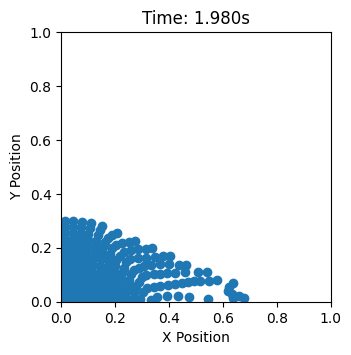

In [20]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Create figure and axis
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.set_xlim(0, 1.0)
ax.set_ylim(0, 1.0)
ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')
ax.set_title('Granular Column Collapse')

# Initialize scatter plot
scatter = ax.scatter([], [])

# Animation update function
def update(frame):
    scatter.set_offsets(pos[frame * interval])
    ax.set_title(f'Time: {ta[frame]:.3f}s')
    ax.set_aspect('equal')
    return scatter,

# Create animation
# Using the same interval as your save interval
anim = FuncAnimation(
    fig, update, 
    frames=len(ta),  # number of frames matches saved timesteps
    interval=50,     # 50ms between frames
    blit=True
)

# Display animation in notebook
HTML(anim.to_jshtml())